In [1]:
from shared_2D import *

# Problem setup
- 49 x 50 atoms.
- normalized interatomic-spacing $2^{1/6}$
- outermost 3 layers are atomistic
- no point defects
- initial 5 rep-atoms are handpicked and then kmeans-equilibrated
- boundary conditions 
    - atom at origin is fixed in x and y direction
    - atoms along x-axis are constrained in y
    - atom along y-axis are constrained in x

## Global params

In [3]:
# problem specification
NX, NY = 49, 50
LATTICE_SPACING = 2**(1/6)
BORDER_LAYERS = 3
CUTOFF_FACTOR = 1.9
MAX_ITER = 10000
LOG_EVERY = 100
PINN_HISTORY_JSON_FILENAME = "pinn_history/pinn-history-2d-recluster-defgrad.json"
MIN_EPOCHS_BEFORE_RECLUSTER = 1000
RECLUSTER_EVERY = 500
DEFGRAD_TRIGGER_TOL = 1.0e-6
DEFGRAD_JUMP_TOL = 5.0e-8
DEFGRAD_JUMP_MAD_FACTOR = 3.0
MIN_SPLIT_CLUSTER_SIZE = 10
MIN_DISCONTINUITY_EDGES = 3

## Generate lattice
- split into `continuum` and `atomistic` atoms. Outer 3 layers of atoms are made `atomistic`
- manually pick 5 `rep-atoms` evenly distributed
- equilibrate the `rep-atoms` using `kmeans_unweighted`

neighbor counts: (array([2, 3, 4, 5, 6]), array([   2,   50,   94,   48, 2256]))
max neighbors: 6
number of atoms 		 2450
atomistic atoms 		 558
continuum atoms 		 1892
initial rep atom indices 	 [1200  350  384 2065 2099]
final rep atom indices 		 [1200  600  624 1825 1849]
cac_weights 			 [302. 396. 396. 398. 400.]
sum of cac_weights 			 1892.0


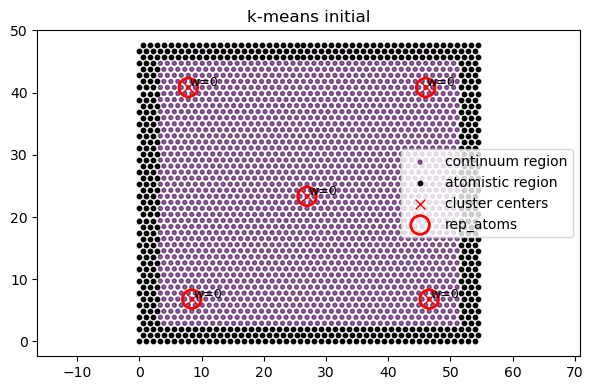

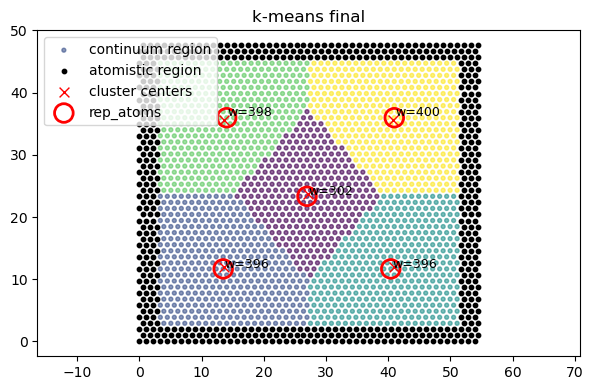

In [6]:
atom_pos = make_triangular_lattice(NX,NY,LATTICE_SPACING)

# 3 layers of atoms bordering the square are flagged as atomistic-region
atomistic_indices,continuum_indices = split_atomistic_continuum(NX,NY,BORDER_LAYERS)
continuum_atom_pos = atom_pos[continuum_indices]
atomistic_atom_pos = atom_pos[atomistic_indices]

# manually pick 5 rep_atoms among the continuum atoms 
initial_rep_indices, rep_targets = pick_manual_rep_atoms(atom_pos,continuum_indices,0.1)

neighs = build_first_neighbor_list(atom_pos, spacing=LATTICE_SPACING)

neighbor_counts = np.array([len(nbrs) for nbrs in neighs])
print("neighbor counts:", np.unique(neighbor_counts, return_counts=True))
print("max neighbors:", neighbor_counts.max())

# compute deformation-gradient. this is just identity because we havent done any deformation yet
F_full, q_defgrad_full, valid_full = local_deformation_gradient(reference_pos=atom_pos,current_pos=atom_pos,neighs=neighs,)
q_continuum = q_defgrad_full[continuum_indices] # this is just an array of 1's
# assign continuum-atoms to their clusters, and equilibrate over 100 iterations of kmeans 
cluster_idx, centers, rep_indices, cac_weights, history = kmeans_weighted(
    atom_pos=atom_pos,
    continuum_indices=continuum_indices,
    initial_rep_indices=initial_rep_indices, 
    importance_weights=q_continuum
    )

print("number of atoms \t\t", len(atom_pos))
print("atomistic atoms \t\t", len(atomistic_indices))
print("continuum atoms \t\t", len(continuum_indices))
print("initial rep atom indices \t", initial_rep_indices)
print("final rep atom indices \t\t", rep_indices)
print("cac_weights \t\t\t", cac_weights)
print("sum of cac_weights \t\t\t", cac_weights.sum())

plot_partition(atom_pos, atomistic_indices, continuum_indices, [0]*len(continuum_indices), initial_rep_indices, atom_pos[initial_rep_indices],[0 for i in range(initial_rep_indices.size)], figure_size=(6,4),plot_title="k-means initial")
plot_partition(atom_pos, atomistic_indices, continuum_indices, cluster_idx, rep_indices, centers,cac_weights, figure_size=(6,4),plot_title="k-means final")

### Setup the neighborlist once
### normalize inputs
### generate mask+offset for Dirichlet BCs
### setup 2D PINN

In [7]:
# normalized inputs
r0,r0_norm = generate_normalized_input(atom_pos=atom_pos)

# mask for applying dirichlet boundary condition. this is a very specific Dirichlet BC
mask,u_prescribed = generate_dirichlet_mask(r0=r0, atom_pos=atom_pos)

### Set up the neighbrlist once:
pair_i_np, pair_j_np = build_reference_pair_list(atom_pos, cutoff = CUTOFF_FACTOR*LATTICE_SPACING)
pair_i = torch.tensor(pair_i_np, dtype=TORCH_LONG, device=TORCH_DEVICE)
pair_j = torch.tensor(pair_j_np, dtype=TORCH_LONG, device=TORCH_DEVICE)

# initialize the PINN 
model = PINN2D().to(device=TORCH_DEVICE, dtype=TORCH_FLOAT)
adam_opt = torch.optim.Adam(model.parameters(), lr=1e-4) # optimizer adjusts the weights of the NN


atomistic_indices_t = torch.tensor(atomistic_indices, dtype=TORCH_LONG, device=TORCH_DEVICE)
rep_indices_t = torch.tensor(rep_indices, dtype=TORCH_LONG, device=TORCH_DEVICE)
cac_weights_t = torch.tensor(cac_weights, dtype=TORCH_FLOAT, device=TORCH_DEVICE)


In [8]:
import json 
def do_train_recluster_defgradvar():
    global cluster_idx
    global rep_indices
    global cac_weights
    global rep_indices_t
    global cac_weights_t
    global adam_opt

    max_iter = 10000
    print_every = 100
    mismatch_threshold = 3e-6   # mismatch-norm =%
    min_epoch_before_recluster = 1000
    recluster_every = 500
    with open(PINN_HISTORY_JSON_FILENAME, "w") as jsonfile:
        jsonfile.write("[\n")
        first_row = True

        for epoch in range(max_iter):
            adam_opt.zero_grad()

            u_raw = model(r0_norm)
            u = mask * u_raw + u_prescribed
            pos = r0 + u # postion at current epoch


            # Efficient site energies from fixed reference pair list
            site_E = site_energies_from_pair_list(pos, pair_i, pair_j)

            # energy of "atomistic-atoms"
            atomistic_energy = site_E[atomistic_indices_t].sum()
            
            # energy of clusters
            cluster_energy = torch.sum(cac_weights_t * site_E[rep_indices_t])

            # total internal energy (used as loss function)
            loss_energy = atomistic_energy + cluster_energy    

            # true all-atom energy
            true_energy = site_E.sum()

            loss_energy.backward()
            adam_opt.step()

            if epoch >= MIN_EPOCHS_BEFORE_RECLUSTER and epoch % RECLUSTER_EVERY == 0:
                # Recompute current position after optimizer step
                with torch.no_grad():
                    u_raw_eval = model(r0_norm)
                    u_eval = mask * u_raw_eval + u_prescribed
                    pos_eval = r0 + u_eval
                    current_pos_np = pos_eval.detach().cpu().numpy()

                did_recluster, recluster_info = (
                    recluster_deformation_gradient_weighted(
                        atom_pos_ref=atom_pos,
                        current_pos_np=current_pos_np,
                        continuum_indices=continuum_indices,
                        cluster_idx=cluster_idx,
                        rep_indices=rep_indices,
                        cac_weights=cac_weights,
                        neighs=neighs,
                        trigger_tol=DEFGRAD_TRIGGER_TOL,
                        jump_tol=DEFGRAD_JUMP_TOL,
                        jump_mad_factor=DEFGRAD_JUMP_MAD_FACTOR,
                        min_split_cluster_size=MIN_SPLIT_CLUSTER_SIZE,
                        min_cut_edges=MIN_DISCONTINUITY_EDGES,
                        max_iter=100,
                        tol=1e-10,
                    )
                )
                print(
                    "epoch", epoch,
                    "defgrad quadrature error",
                    recluster_info["rel_defgrad_quad_error"],
                    "full",
                    recluster_info["full_defgrad_value"],
                    "reduced",
                    recluster_info["reduced_defgrad_value"],
                )

                if did_recluster:
                    split_info = recluster_info["split_info"]

                    print(
                        "quadrature triggered:",
                        recluster_info["quadrature_triggered"],
                    )
                    print(
                        "discontinuity triggered:",
                        recluster_info["discontinuity_triggered"],
                    )
                    print(
                        "clusters:",
                        split_info["num_clusters_before"],
                        "->",
                        split_info["num_clusters_after"],
                    )

                    for split in split_info["splits"]:
                        print("split:", split)

                    print(f"Re-clustering at epoch {epoch} using deformation-gradient weighted K-means")

                    cluster_idx = recluster_info["cluster_idx"]
                    centers = recluster_info["centers"]
                    rep_indices = recluster_info["rep_indices"]
                    cac_weights = recluster_info["cac_weights"]

                    rep_indices_t = torch.tensor(rep_indices,dtype=TORCH_LONG,device=TORCH_DEVICE)

                    cac_weights_t = torch.tensor(cac_weights,dtype=TORCH_FLOAT,device=TORCH_DEVICE,)

                    assert len(cluster_idx) == len(continuum_indices)
                    assert len(rep_indices) == len(cac_weights)
                    assert np.isclose(cac_weights.sum(), len(continuum_indices))
                    assert set(rep_indices).issubset(set(continuum_indices))

                    # Reset optimizer because the loss changed discontinuously
                    adam_opt = torch.optim.Adam(model.parameters(), lr=1e-4)

                    print("new rep_indices:", rep_indices)
                    print("new weights:", cac_weights)
                    print("sum weights:", cac_weights.sum())

            ################################3
            # log progress
            if epoch % LOG_EVERY == 0:
                row = {
                    "epoch": int(epoch),
                    "loss_energy": loss_energy.detach().cpu().item(),
                    "true_energy": true_energy.detach().cpu().item(),
                    "pos": pos.detach().cpu().tolist(),
                    "rep_indices":rep_indices.tolist()
                }
        
                if not first_row:
                    jsonfile.write(",\n")
        
                jsonfile.write(json.dumps(row))
                first_row = False

                print(epoch, float(loss_energy.detach()))
                jsonfile.flush()


        jsonfile.write("\n]\n")


## Compare `loss-energy` vs `true-energy` (both calculated by PYTHON)
- `loss-energy` is the coarse-grained energy that is used as the objective function in training the PINN
- `true-energy` is the fully atomistic energy of the system.

In [9]:
# read in the PINN output file evaluated from HYDRA
import json
jsonfilename = PINN_HISTORY_JSON_FILENAME

# Load history
with open(jsonfilename, "r") as jsonfile:
    history = json.load(jsonfile)

# Extract data
epochs = np.array([row["epoch"] for row in history])
loss_energy = np.array([row["loss_energy"] for row in history])
true_energy = np.array([row["true_energy"] for row in history])
pos = np.array([row["pos"] for row in history])

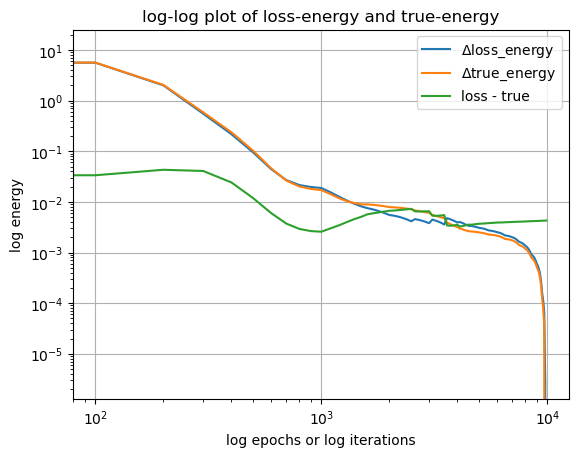

In [10]:
# Plot
plt.figure()
plt.plot(epochs, loss_energy-loss_energy[-1] ,label='$\\Delta$loss_energy')
plt.plot(epochs, true_energy-true_energy[-1] ,label='$\\Delta$true_energy')
plt.plot(epochs, np.abs(loss_energy - true_energy),label='loss - true')
plt.xlabel("log epochs or log iterations")
plt.ylabel("log energy")
plt.title("log-log plot of loss-energy and true-energy")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

# Compare with LAMMPS

In [11]:
from shared_lammps_2D import *

LAMMPS_DIR          =   "./lammps_2d_input_output/"
LAMMPS_TRAJ_FILE    =   LAMMPS_DIR + "relax_2d_traj.lammpstrj"
LAMMPS_ENERGY_LOG   =   LAMMPS_DIR + "relax_2d_energy.log"

### Read in the LAMMPS `trajectory` file

In [12]:
timesteps, lammps_frames = read_lammps_trajectory_xy(LAMMPS_TRAJ_FILE)

print(timesteps.shape)
print(lammps_frames.shape)
# shape: (n_frames, n_atoms, 2)

(101,)
(101, 2450, 2)


## Evaluate the `relative-error` in `displacement-vector-field`
$$ \vec{e(t)}_{disp}  = \frac{\lVert \vec{u(t)}_P - \vec{u(t)}_L \rVert}{\lVert \vec{u(t)}_{L} \rVert} $$
- $\vec{u(t)}_P$ is the displacement field predicted by the PINN model at epoch $t$
- $\vec{u(t)}_L$ is the displacement field evaluated by the LAMMPS simulation at iteration $t$

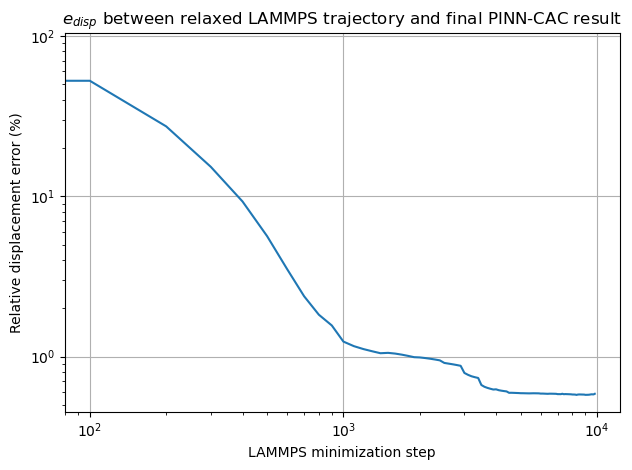

In [13]:
def relative_displacement_error(u_ref, u_pred):
    return np.linalg.norm(u_ref - u_pred) / np.linalg.norm(u_ref)

errors = []

for i in range(1,len(pos)):
    u_lammps = lammps_frames[i] - atom_pos
    u_pinn = pos[i]  - atom_pos
    err = relative_displacement_error(u_lammps,u_pinn)
    errors.append(err)
errors = np.array(errors)

plt.figure()
plt.plot(np.arange(len(errors))*100, 100*errors)
plt.xlabel("LAMMPS minimization step")
plt.ylabel("Relative displacement error (%)")
plt.title("$e_{disp}$ between relaxed LAMMPS trajectory and final PINN-CAC result")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [14]:
u_lammps_mags = np.linalg.norm(lammps_frames-atom_pos,axis=2)
u_pinn_mags = np.linalg.norm(pos-atom_pos,axis=2)
relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))

/tmp/ipykernel_523513/2592136731.py:3: RuntimeWarning: invalid value encountered in divide
  relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))


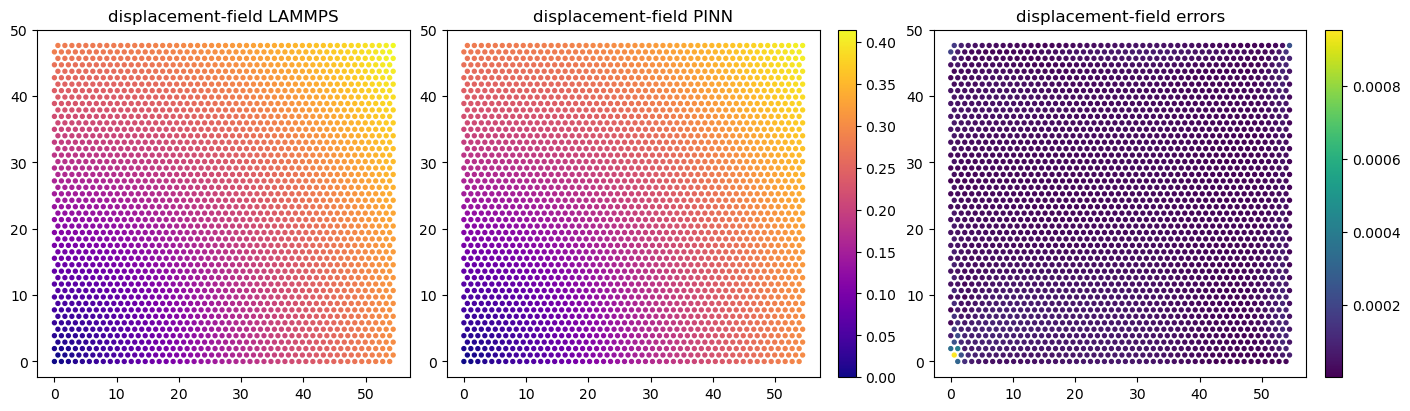

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')

vmin = np.min([np.min(u_pinn_mags[-1]),np.min(u_lammps_mags[-1])])
vmax = np.max([np.max(u_pinn_mags[-1]),np.max(u_lammps_mags[-1])])

scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_lammps_mags[-1],cmap='plasma',s=8,alpha=1,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_pinn_mags[-1],cmap='plasma',s=8,alpha=1,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("displacement-field LAMMPS")
ax2.set_title("displacement-field PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=relative_err_mags[-1],cmap='viridis',s=8,alpha=1,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("displacement-field errors")

plt.show()

## Evaluate the `relative-error` in `bond-length-vector`
$$ \vec{err(t)}_{bond}  = \frac{\lVert \vec{b(t)}_P - \vec{b(t)}_L \rVert}{\lVert \vec{b(t)}_{L} \rVert} $$
- bond-length is a vector $\vec{b} = \{b_1, b_2, b_3, ... b_{N_A} \}$ where $b_i$ is the bond-length of atom $i$
- Bond-Length of atom $a$ is given by $\frac{1}{2} \Sigma_{b} \lVert \vec{r_a(t)} - \vec{r_b(t)} \rVert$ where the summation is over all atoms $b$ in the first-nearest-neighbor of atom $a$
- $\vec{b(t)}_P$ is the bond-length vector predicted by the PINN model at epoch $t$
- $\vec{b(t)}_L$ is the bond-length vector evaluated by the LAMMPS simulation at iteration $t$
- NOTE: first-neighbors are evaluated at the referernce configuration (zeroth iteration) 

In [16]:
# find the bond-length-vectors at all times
bond_lengths_lammps = []
bond_lengths_pinn = []
bond_lengths_errors = []
for i in range(len(pos)):
    err_bond, b_lammps, b_pinn = relative_bond_length_error(
        pos0=atom_pos,
        pos_lammps=lammps_frames[i+1],
        pos_pinn=pos[i],
        spacing=2**(1/6),
    )
    bond_lengths_errors.append(err_bond)
    bond_lengths_lammps.append(b_lammps)
    bond_lengths_pinn.append(b_pinn)

bond_lengths_errors = np.array(bond_lengths_errors)
bond_lengths_lammps = np.array(bond_lengths_lammps)
bond_lengths_pinn = np.array(bond_lengths_pinn)

print(f"bond-length error at final iteration/epoch = {100 * bond_lengths_errors[-1]:.6f}%")

bond-length error at final iteration/epoch = 0.019978%


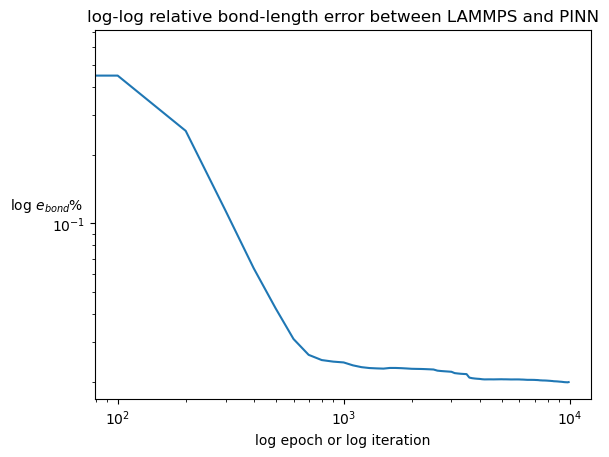

In [17]:
plt.plot(epochs,100*bond_lengths_errors)
plt.yscale('log')
plt.xscale('log')
plt.title('log-log relative bond-length error between LAMMPS and PINN')
plt.xlabel('log epoch or log iteration')
plt.ylabel('log $e_{bond}$%',rotation=0)
plt.show()

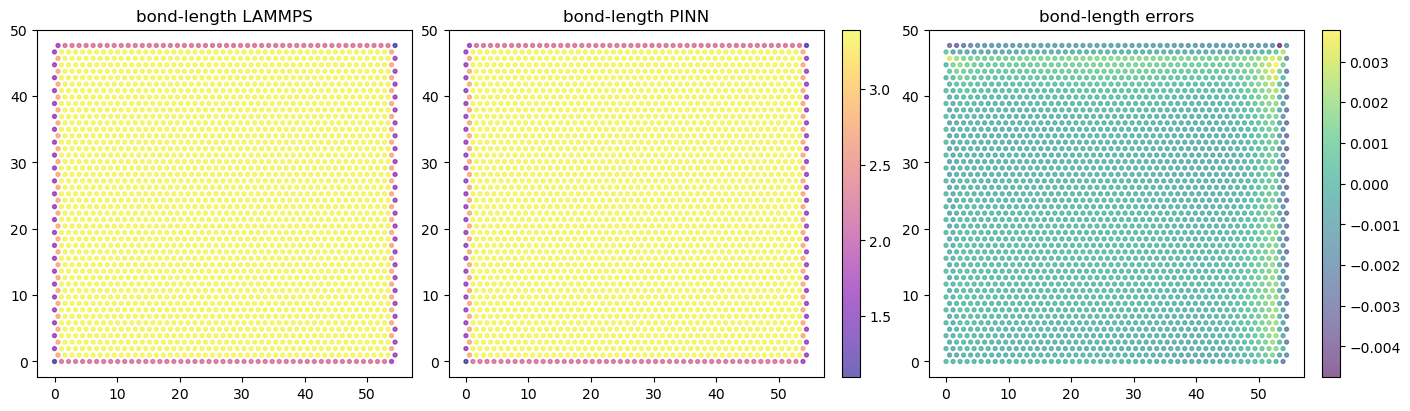

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
vmin = np.min([np.min(bond_lengths_lammps),np.min(bond_lengths_pinn)])
vmax = np.max([np.max(bond_lengths_lammps),np.max(bond_lengths_pinn)])
scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_lammps[-1],cmap='plasma',s=8,alpha=0.6,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1],cmap='plasma',s=8,alpha=0.6,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("bond-length LAMMPS")
ax2.set_title("bond-length PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1]-bond_lengths_lammps[-1],cmap='viridis',s=8,alpha=0.6,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("bond-length errors")

plt.show()

## Evaluate the `relative-error` in `total-energy`
$$ err(t)_{E}  = \frac{\lVert E(t)_P - E(t)_L \rVert}{\lVert E(t)_L \rVert} $$
- $E(t)_P$ is the total `coarse-grained-energy` predicted by the PINN model at epoch $t$. 
- $E(t)_L$ is the total `atomistic-energy` evaluated by the LAMMPS simulation at iteration $t$
- The `coarse-grained-energy` is the `loss` function in the PINN. 

### Read in the LAMMPS `energy-logs`

In [19]:
steps, pe, fnorm, fmax = read_lammps_thermo_energy(LAMMPS_ENERGY_LOG)

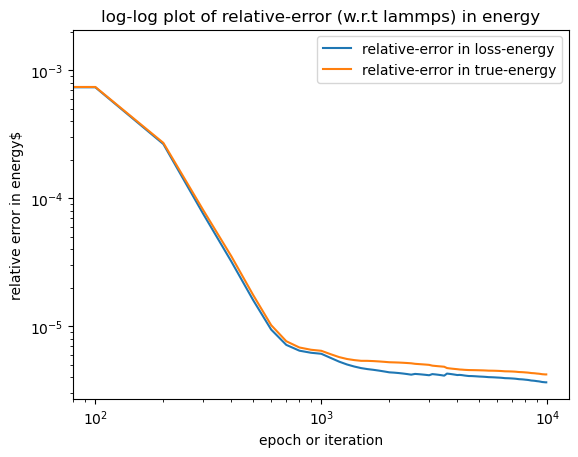

In [20]:
loss_energy_err = np.abs(loss_energy - pe[1:])/np.abs(pe[1:])
true_energy_err = np.abs(true_energy - pe[1:])/np.abs(pe[1:])
plt.plot(epochs,loss_energy_err,label='relative-error in loss-energy')
plt.plot(epochs,true_energy_err,label='relative-error in true-energy')
plt.yscale('log')
plt.xscale('log')
plt.title('log-log plot of relative-error (w.r.t lammps) in energy')
plt.ylabel('relative error in energy$')
plt.xlabel('epoch or iteration')
plt.legend()
plt.show()

# Export reclustering as GIF

In [28]:
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import Normalize


def load_pinn_history(json_filename):
    with open(json_filename, "r") as f:
        return json.load(f)


def animate_pinn_history_gif(
    json_filename,
    output_gif="pinn_relaxation.gif",
    fps=10,
    atom_size=12,
    rep_size=120,
    percentile_limits=(1.0, 99.0),
):
    history = load_pinn_history(json_filename)

    if len(history) == 0:
        raise ValueError("JSON history is empty.")

    missing_q = [
        frame_id
        for frame_id, entry in enumerate(history)
        if "q_full" not in entry
    ]

    if missing_q:
        raise KeyError(
            f"q_full is missing from {len(missing_q)} frame(s). "
            f"First missing frame: {missing_q[0]}"
        )

    all_pos = np.asarray(
        [entry["pos"] for entry in history],
        dtype=np.float64,
    )

    all_q = np.asarray(
        [entry["q_full"] for entry in history],
        dtype=np.float64,
    )

    if all_pos.ndim != 3 or all_pos.shape[2] != 2:
        raise ValueError(
            "Position history must have shape "
            "(n_frames, n_atoms, 2)."
        )

    n_frames, n_atoms, _ = all_pos.shape

    if all_q.shape != (n_frames, n_atoms):
        raise ValueError(
            "q_full history must have shape "
            f"({n_frames}, {n_atoms}), "
            f"but received {all_q.shape}."
        )

    finite_q = all_q[np.isfinite(all_q)]

    if finite_q.size == 0:
        raise ValueError("q_full contains no finite values.")

    lower_percentile, upper_percentile = percentile_limits

    q_min = np.percentile(finite_q, lower_percentile)
    q_max = np.percentile(finite_q, upper_percentile)

    # Avoid a degenerate color scale when q is initially constant.
    if np.isclose(q_min, q_max):
        q_center = q_min
        q_padding = max(abs(q_center) * 1.0e-6, 1.0e-12)
        q_min = q_center - q_padding
        q_max = q_center + q_padding

    color_norm = Normalize(vmin=q_min, vmax=q_max)

    x_min = np.nanmin(all_pos[:, :, 0])
    x_max = np.nanmax(all_pos[:, :, 0])
    y_min = np.nanmin(all_pos[:, :, 1])
    y_max = np.nanmax(all_pos[:, :, 1])

    x_range = x_max - x_min
    y_range = y_max - y_min

    pad_x = 0.05 * x_range if x_range > 0.0 else 1.0
    pad_y = 0.05 * y_range if y_range > 0.0 else 1.0

    fig, ax = plt.subplots(figsize=(9, 7))

    pos0 = all_pos[0]
    q0 = all_q[0]

    atoms_scatter = ax.scatter(
        pos0[:, 0],
        pos0[:, 1],
        c=q0,
        s=atom_size,
        cmap="viridis",
        norm=color_norm,
        edgecolors="none",
    )

    rep_indices0 = np.asarray(
        history[0].get("rep_indices", []),
        dtype=int,
    )

    rep_pos0 = (
        pos0[rep_indices0]
        if len(rep_indices0) > 0
        else np.empty((0, 2))
    )

    reps_scatter = ax.scatter(
        rep_pos0[:, 0],
        rep_pos0[:, 1],
        s=rep_size,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        label="Representative atoms",
    )

    colorbar = fig.colorbar(
        atoms_scatter,
        ax=ax,
        pad=0.02,
    )
    colorbar.set_label(r"$q_i=\|\mathbf{F}_i-\mathbf{I}\|_F$")

    title = ax.set_title("")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)
    ax.legend(loc="upper right")

    def update(frame_id):
        entry = history[frame_id]

        pos = all_pos[frame_id]
        q_full = all_q[frame_id]

        atoms_scatter.set_offsets(pos)
        atoms_scatter.set_array(q_full)

        rep_indices = np.asarray(
            entry.get("rep_indices", []),
            dtype=int,
        )

        if len(rep_indices) > 0:
            reps_scatter.set_offsets(pos[rep_indices])
        else:
            reps_scatter.set_offsets(np.empty((0, 2)))

        epoch = int(entry["epoch"])
        loss_energy = float(entry["loss_energy"])
        true_energy = entry.get("true_energy")

        title_text = (
            "PINN 2D deformation-gradient re-clustering\n"
            f"epoch={epoch}, loss={loss_energy:.6e}"
        )

        if true_energy is not None:
            title_text += (
                f", true energy={float(true_energy):.6e}"
            )

        title_text += (
            f"\nrepresentative atoms={len(rep_indices)}, "
            f"q max={np.nanmax(q_full):.3e}"
        )

        title.set_text(title_text)

        return atoms_scatter, reps_scatter, title

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=1000.0 / fps,
        blit=False,
    )

    animation.save(
        output_gif,
        writer=PillowWriter(fps=fps),
        dpi=120,
    )

    plt.close(fig)
    print(f"Saved GIF to: {output_gif}")

In [29]:
animate_pinn_history_gif(
    json_filename=PINN_HISTORY_JSON_FILENAME,
    output_gif="figs/pinn_2d_recluster_defgrad.gif",
    fps=2)

Saved GIF to: figs/pinn_2d_recluster_defgrad.gif


In [33]:
animate_pinn_history_gif(
    json_filename="pinn_history/pinn-history-2d-neumann-reclusterDEFGRAD.json",
    output_gif="figs/pinn_2d_neumann_reclusterDEFGRAD.gif",
    fps=2)

Saved GIF to: figs/pinn_2d_neumann_reclusterDEFGRAD.gif


### observations: 
- it looks like it's breathing.
- the lattice expands and a gash appears in the middle,
- rep-atoms are moved around
- the lattice contracts and the gash disappears 

![Alt Text](figs/pinn_2d_neumann_reclusterDEFGRAD.gif)